In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage
import pandas as pd
import os
import math

#Pending 006 , 007, 008
image_path = r'Clenead_Images\Bele-Karen_cleaned\XY\XY15.tif'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
scene_coordinate_system = -16.41414 #Variable depending of the image

#Scale the values based of the scale
height_pixels, width_pixels = image.shape[:2]
scale_mm = 4.5 / 208  #mm x pixel
with_mm = width_pixels * scale_mm #
high_mm = height_pixels * scale_mm

# Coordenadas que no deseas analizar
rect1_points = [(589, 860), (1002, 858), (590, 934), (1002, 933)]
rect2_points = [(480, 114), (481, 2), (1, 2), (1, 114)]
rect3_points = [(1178, 2), (1177, 251), (1470, 252), (1470, 2)]
rect4_points = [(190, 724), (1, 723), (4, 934), (191, 931)]
rect5_points = [(1325, 861), (1468, 864), (1468, 931), (1327, 933)]

rectangles = [rect1_points, rect2_points, rect3_points, rect4_points, rect5_points]


print(f"Dimensiones de la imagen: {width_pixels}x{height_pixels} píxeles")
print(f"Escala: {scale_mm:.6f} mm/px")
print(f"Dimensiones de la imagen en milímetros: {with_mm:.2f}mm x {high_mm:.2f}mm")

Dimensiones de la imagen: 1466x933 píxeles
Escala: 0.021635 mm/px
Dimensiones de la imagen en milímetros: 31.72mm x 20.19mm


Detect sworms

In [51]:
# Definir umbrales
max_area_threshold = 5000  # Umbral máximo de área
min_area_threshold = 200   # Umbral mínimo de área
# 1. Suavizar la imagen para reducir ruido
blur = cv2.GaussianBlur(image, (31, 31), 0)

# 2. Binarizar usando umbral de Otsu
_, binary = cv2.threshold(blur, 250, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Operaciones morfológicas para limpiar pequeñas manchas y separar un poco las burbujas
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
binary_opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=4)

# 4. Usar operaciones de cierre para juntar las formas más brillantes
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7))  # Se puede ajustar el tamaño del kernel
binary_closed = cv2.morphologyEx(binary_opened, cv2.MORPH_CLOSE, kernel_close)

# 5. Encontrar contornos de las formas brillantes
contours, _ = cv2.findContours(binary_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 6. Filtrar los contornos por área
valid_contours = []
for contour in contours:
    area = cv2.contourArea(contour)
    
    if min_area_threshold <= area <= max_area_threshold:
        valid_contours.append(contour)

# 7. Dibujar los contornos válidos en la imagen original
result_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)  # Convertir a color para visualización

for contour in valid_contours:
    cv2.drawContours(result_image, [contour], -1, (0, 255, 0), 2)  # Dibujar en verde

    

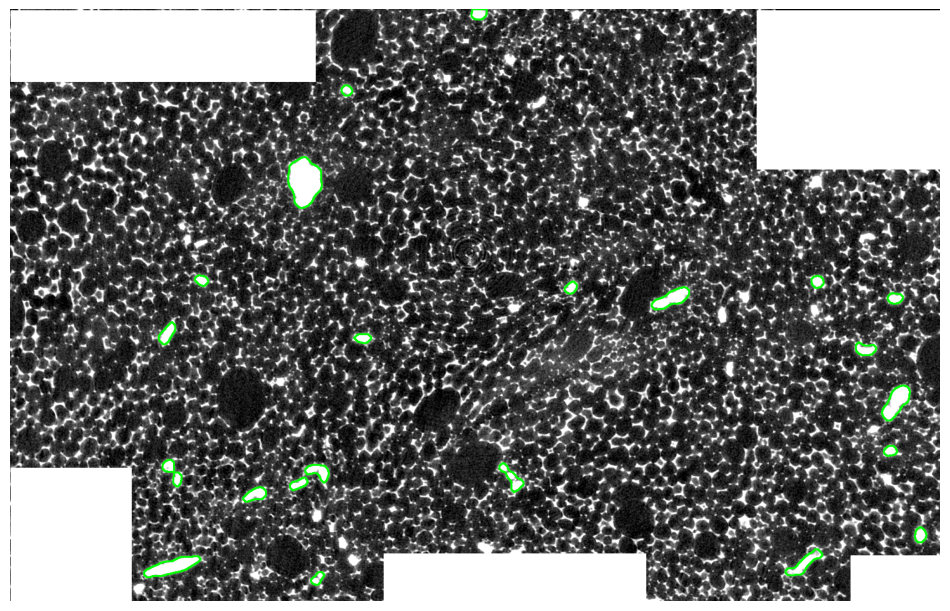

In [52]:
#Mostrar el resultado 
plt.figure(figsize=(12, 12))
plt.imshow(result_image)
plt.axis('off')
plt.show()



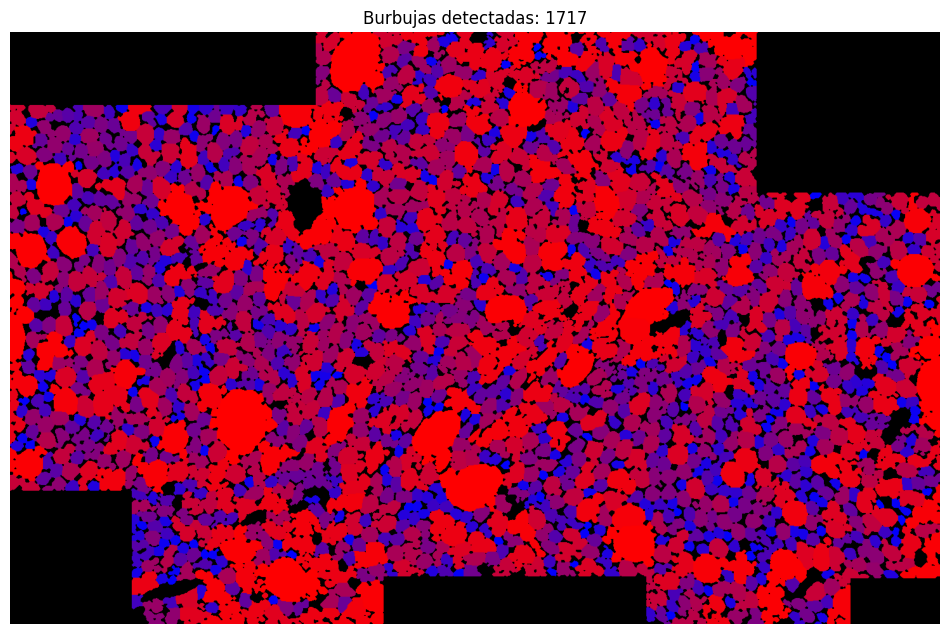

In [53]:
# Definir umbrales
max_area_threshold = 10000 #10000
min_area_threshold = 0    # Umbral

# 1. Suavizar la imagen para reducir ruido
blur = cv2.GaussianBlur(image, (3, 3), 0) #23,23,(<008) 5,5(blackers-009)

# 2. Binarizar usando umbral de Otsu
_, binary = cv2.threshold(blur, 80, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


# 3. Operaciones morfológicas para limpiar pequeñas manchas y separar un poco las burbujas
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3)) # 15 15, 3,3(blackers - 009)
binary_opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

# 4.Transformada de distanci
dist_transform = cv2.distanceTransform(binary_opened, cv2.DIST_L2, 5)

# 5. Encontrar los picos locales en la transformada de distancia
coordinates = peak_local_max(dist_transform, min_distance=10,threshold_abs=0.5) # 27 
local_max = np.zeros(dist_transform.shape, dtype=bool)
local_max[tuple(coordinates.T)] = True




# Etiquetar los picos para usarlos como marcadores en watershed
markers, _ = ndimage.label(local_max)

# 6.  la transformada de distancia negativa (para encontrar valles)
labels = watershed(-dist_transform, markers, mask=binary_opened)

# 7.Resultado
num_labels = labels.max()
areas = []
valid_count = 0


for lbl in range(1, num_labels+1):
    mask = (labels == lbl).astype(np.uint8)
    area = cv2.countNonZero(mask)
    
    
    # Filtrar por área 
    if min_area_threshold <= area <= max_area_threshold:
        areas.append((lbl,area))
        valid_count += 1
areas = sorted(areas,key=lambda x: x[1])
gradient_colors = np.linspace(0,255,len(areas),dtype=np.uint8)
colored_result = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)

for i, (lbl, area) in enumerate(areas):
    # Asignar un color basado en el índice del gradiente
    color = (255 - gradient_colors[i], 0, gradient_colors[i])  # Azul -> Rojo
    colored_result[labels == lbl] = color

    


plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(colored_result, cv2.COLOR_BGR2RGB))
plt.title(f"Burbujas detectadas: {valid_count}")
plt.axis('off')
plt.show()